#ESE 3600 Final project resistor classifier

##Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, Model
from keras.preprocessing import image_dataset_from_directory
from google.colab import files
from IPython.display import display
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import os

In [ ]:
# Define filenames and set up directory structure
MODELS_DIR = 'models'
if not os.path.exists(MODELS_DIR):
  os.mkdir(MODELS_DIR)
SAVED_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand")
FLOAT_TFL_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand_float.tfl")
QUANTIZED_TFL_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.tfl")
TFL_CC_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.cc")

DATASET_DIR =  'dataset'
if not os.path.exists(DATASET_DIR):
  os.mkdir(DATASET_DIR)
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")
!rm -rf sample_data

CHKPT_DIR =  'checkpoints'
if not os.path.exists(CHKPT_DIR):
  os.mkdir(CHKPT_DIR)

##Dataset

In [ ]:
import zipfile
import os

# Example if you uploaded dataset.zip
with zipfile.ZipFile('Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('raw')

data_dir = 'raw'  # path to your extracted dataset

import shutil

# Remove __MACOSX if it exists
macosx_folder = os.path.join(data_dir, '__MACOSX')
if os.path.exists(macosx_folder):
    shutil.rmtree(macosx_folder)
    print("__MACOSX folder removed")
else:
    print("No __MACOSX folder found")

No __MACOSX folder found


In [ ]:
# Choose a Train, validation, test Split Pecentage for your dataset
TEST_PERCENTAGE = 10
VALIDATION_PERCENTAGE = 10
TRAIN_PERCENTAGE = 80

In [ ]:
TRAIN_DIR = "/content/dataset/train"
VAL_DIR = "/content/dataset/val"
TEST_DIR = "/content/dataset/test"

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

EXTRACT_DIR = 'raw'
class_names = sorted([d.name for d in os.scandir(EXTRACT_DIR) if d.is_dir()])

# Create class subdirectories
for class_name in class_names:
    os.makedirs(os.path.join(TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, class_name), exist_ok=True)

# Split into train/val/test
import shutil
from sklearn.model_selection import train_test_split

print(f"\nSplitting into train ({TRAIN_PERCENTAGE}%), val ({VALIDATION_PERCENTAGE}%), test ({TEST_PERCENTAGE}%)...")

for class_name in class_names:

    class_dir = os.path.join(EXTRACT_DIR, class_name)
    files = [f for f in os.listdir(class_dir) if (f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg') or f.endswith('.PNG') or f.endswith('.JPG') or f.endswith('.JPEG'))]

    #test
    train_val_files, test_files = train_test_split(
        files,
        test_size=TEST_PERCENTAGE / 100.0,
        random_state=42
    )

    #val from remaining
    train_files, val_files = train_test_split(
        train_val_files,
        test_size=VALIDATION_PERCENTAGE / (TRAIN_PERCENTAGE + VALIDATION_PERCENTAGE),
        random_state=42
    )

    for f in train_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(TRAIN_DIR, class_name, f)
        shutil.copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(VAL_DIR, class_name, f)
        shutil.copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(TEST_DIR, class_name, f)
        shutil.copy2(src, dst)

    print(f"{class_name}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")

print(f"\nDataset split complete!")
print(f"Train: {TRAIN_DIR}")
print(f"Val: {VAL_DIR}")
print(f"Test: {TEST_DIR}")


Splitting into train (80%), val (10%), test (10%)...
180K: 312 train, 39 val, 40 test
1K5: 303 train, 38 val, 38 test
220R: 277 train, 35 val, 35 test
390R: 293 train, 37 val, 37 test
47R: 302 train, 38 val, 38 test
4M7: 274 train, 35 val, 35 test
560K: 301 train, 38 val, 38 test
5K6: 314 train, 40 val, 40 test
6K8: 312 train, 40 val, 40 test
Idle: 316 train, 40 val, 40 test

Dataset split complete!
Train: /content/dataset/train
Val: /content/dataset/val
Test: /content/dataset/test


In [ ]:
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224

print("\nCreating TensorFlow datasets...")

train_ds_raw = image_dataset_from_directory(
    directory=TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=16,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    shuffle=True,
    seed=42
)

validation_ds_raw = image_dataset_from_directory(
    directory=VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=16,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    shuffle=False
)

test_ds_raw = image_dataset_from_directory(
    directory=TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=16,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    shuffle=False
)

# Get class names from dataset
dataset_class_names = train_ds_raw.class_names
print(f"Dataset classes: {dataset_class_names}")

train_ds = train_ds_raw.prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds_raw.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds_raw.prefetch(buffer_size=tf.data.AUTOTUNE)

#data aug
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


Creating TensorFlow datasets...
Found 3004 files belonging to 10 classes.
Found 380 files belonging to 10 classes.
Found 381 files belonging to 10 classes.
Dataset classes: ['180K', '1K5', '220R', '390R', '47R', '4M7', '560K', '5K6', '6K8', 'Idle']


##Define, Train, and Test Model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    alpha=0.5
)

# Unfreeze last ~30% of the network
for layer in base_model.layers[-10:]:
    layer.trainable = True

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_0.50_224            │ (None, 7, 7, 1280)     │       706,224 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 719,034 (2.74 MB)

 Trainable params: 700,490 (2.67 MB)

 Non-trainable params: 18,544 (72.44 KB)

In [ ]:
# Train the model
EPOCHS = 50

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # Reduce LR by half
    patience=5,        # After 5 epochs with no improvement
    min_lr=1e-7
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,  # Stop if no improvement for 15 epochs
    restore_best_weights=True
)

# Recompile the model with the correct loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy', # Changed from 'sparse_categorical_crossentropy'
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks = [reduce_lr, early_stop]
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 98s 281ms/step - accuracy: 0.2412 - loss: 2.1786 - val_accuracy: 0.1579 - val_loss: 3.3034 - learning_rate: 1.0000e-04
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.7152 - loss: 0.8462 - val_accuracy: 0.2237 - val_loss: 2.8527 - learning_rate: 1.0000e-04
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.8834 - loss: 0.3500 - val_accuracy: 0.1974 - val_loss: 2.9034 - learning_rate: 1.0000e-04
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9501 - loss: 0.1543 - val_accuracy: 0.2421 - val_loss: 2.4509 - learning_rate: 1.0000e-04
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.9606 - loss: 0.1188 - val_accuracy: 0.2237 - val_loss: 2.7264 - learning_rate: 1.0000e-04
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9806 - loss: 0.0676 - val_accuracy: 0.2474 - val_loss: 3.0020 - learning_rate: 1.0000e-04
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/st


Evaluating on test set...
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 663ms/step - accuracy: 1.0000 - loss: 0.0011
Test Accuracy: 1.0000


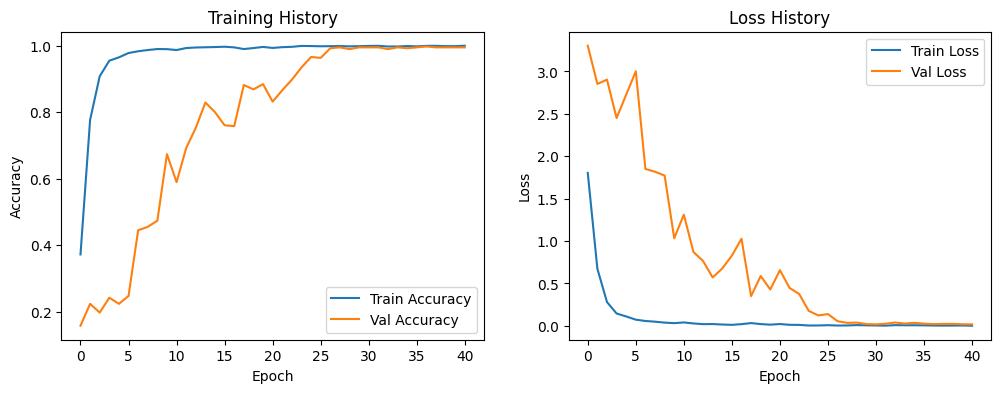

In [ ]:

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training History')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')
plt.show()

In [ ]:
# Save in the modern Keras format
model.save("models/resistor4_3.keras")

# Also export a SavedModel directory (useful for TF ops tooling)
model.export("models/resistor4_3_saved_model")


Saved artifact at 'models/resistor4_3_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_316')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134269519918288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519919440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519919248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519918672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519920208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519904848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519919824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519920592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519918864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519919632: TensorSpec(shape=(), dtype=tf.resource, name=Non

##convert to tflite and Test Model

In [ ]:
# Convert classifier to TFLite

print("Converting classifier to TFLite with int8 quantization...")

# Representative dataset for quantization
def representative_dataset():
    for batch, _ in train_ds.take(100):  # Use 100 batches from training data
        yield [batch]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# For full int8 quantization (best for embedded)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_classifier = converter.convert()

with open('/content/classifier_int8.tflite', 'wb') as f:
    f.write(tflite_classifier)

# Check model sizes
import os
print(f"Classifier (int8): {os.path.getsize('/content/classifier_int8.tflite') / 1024:.1f} KB")

Converting classifier to TFLite with int8 quantization...
Saved artifact at '/tmp/tmp6eygl7el'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_316')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134269519918288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519919440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519919248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519918672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519920208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519904848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519919824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519920592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519918864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269519919632: Tens

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Classifier (int8): 961.0 KB


Input shape: [  1 224 224   3]
Input type: <class 'numpy.uint8'>
Output shape: [ 1 10]
Output type: <class 'numpy.uint8'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



TFLite Model Accuracy: 99.74% (380/381)


<Figure size 800x600 with 0 Axes>

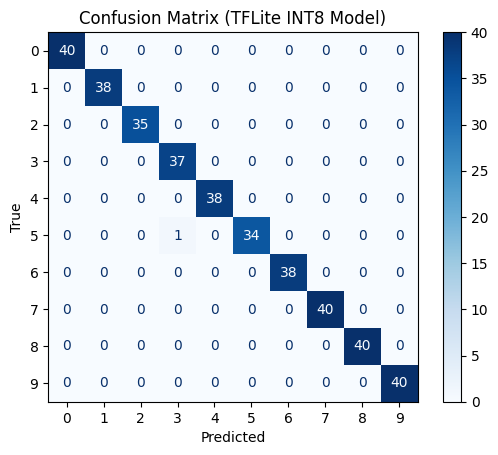

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path='/content/classifier_int8.tflite')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape:", input_details[0]['shape'])
print("Input type:", input_details[0]['dtype'])
print("Output shape:", output_details[0]['shape'])
print("Output type:", output_details[0]['dtype'])

correct = 0
total = 0

all_preds = []
all_labels = []

for images, labels in test_ds:
    for i in range(len(images)):

        # Preprocess image for TFLite
        test_image = images[i:i+1]
        test_image = tf.cast(test_image * 255, tf.uint8)

        # Run inference
        interpreter.set_tensor(input_details[0]['index'], test_image)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        predicted_class = np.argmax(output[0])
        true_class = np.argmax(labels[i])

        all_preds.append(predicted_class)
        all_labels.append(true_class)

        if predicted_class == true_class:
            correct += 1
        total += 1

print(f"\nTFLite Model Accuracy: {correct/total*100:.2f}% ({correct}/{total})")

# ---- CONFUSION MATRIX ---- #
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (TFLite INT8 Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##Tensorflow Lite Micro

In [ ]:
QUANTIZED_TFL_MODEL_FILENAME = '/content/classifier_int8.tflite'
TFL_CC_MODEL_FILENAME = '/content/classifier_model.cc'

# Convert to a C source file for TensorFlow Lite for Microcontrollers
!xxd -i {QUANTIZED_TFL_MODEL_FILENAME} > {TFL_CC_MODEL_FILENAME}

# Update variable names to something meaningful
# Replace the auto-generated name with a clean model name
REPLACE_TEXT = QUANTIZED_TFL_MODEL_FILENAME.replace('/', '_').replace('.', '_')
!sed -i 's/{REPLACE_TEXT}/g_classifier_model_data/g' {TFL_CC_MODEL_FILENAME}

# Print the C source file
print("C header file generated:")
!head -20 {TFL_CC_MODEL_FILENAME}  # Show first 20 lines
print("\n...")
!tail -5 {TFL_CC_MODEL_FILENAME}   # Show last 5 lines (includes array size)

# Also create a header file
TFL_H_MODEL_FILENAME = '/content/classifier_model.h'
with open(TFL_H_MODEL_FILENAME, 'w') as f:
    f.write('#ifndef CLASSIFIER_MODEL_H_\n')
    f.write('#define CLASSIFIER_MODEL_H_\n\n')
    f.write('extern const unsigned char g_classifier_model_data[];\n')
    f.write('extern const unsigned int g_classifier_model_data_len;\n\n')
    f.write('#endif  // CLASSIFIER_MODEL_H_\n')

C header file generated:
unsigned char g_classifier_model_data[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x9c, 0x00, 0x00, 0x00, 0x1c, 0x01, 0x00, 0x00, 0x84, 0x03, 0x0b, 0x00,
  0x94, 0x03, 0x0b, 0x00, 0x04, 0x03, 0x0f, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x10, 0x00, 0x00, 0x00, 0x00, 0x00, 0x0a, 0x00,
  0x10, 0x00, 0x0c, 0x00, 0x08, 0x00, 0x04, 0x00, 0x0a, 0x00, 0x00, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x3c, 0x00, 0x00, 0x00,
  0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f,
  0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x64, 0xff, 0xff, 0xff, 0xae, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00, 0x6f, 0x75, 0x74, 0x70,
  0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00,